In [1]:
# conda activate anndata

import numpy as np
import pandas as pd
import anndata as ad

In [2]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [3]:
sampleinfo = pd.read_csv(f"data/{prefix}_sampleinfo_barcode_level.csv")
orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")
orig_corr = orig_corr.loc[orig_corr['Gene'].isin(expr_ADT_imputed.columns)]
expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

## Align cells between my data and author data

In [4]:
expr_ADT_imputed.index = sampleinfo['Cell_ID']

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [5]:
expr_RNA = expr_RNA.loc[expr_ADT_imputed.index]
expr_ADT = expr_ADT.loc[expr_ADT_imputed.index]

In [6]:
np.all(expr_ADT_imputed.index == expr_ADT.index)

True

In [7]:
np.all(expr_ADT_imputed.index == expr_RNA.index)

True

In [13]:
expr_ADT_imputed.columns

Index(['CD106', 'CD107a', 'CD201', 'CD29', 'CD317', 'Mac2', 'Notch', 'Notch',
       'CD63', 'CD9'],
      dtype='object', name='Protein')

In [14]:
expr_ADT_imputed.columns == orig_corr['Protein']

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

### Calculate correlation between ADT and imputed ADT

In [15]:
expr_ADT_subset = expr_ADT.loc[:, orig_corr['Protein']]

In [ ]:
# expr_ADT_imputed.columns = orig_corr['Protein']

In [18]:
new_corr = expr_ADT_imputed.corrwith(expr_ADT)

In [30]:
corrs_df = (
    orig_corr
    .merge(
        new_corr.rename("New_cor").to_frame(),
        left_on="Protein",
        right_index=True,
        how="inner"   # use "left" if you want to keep all rows of orig_corr
    )
)

In [31]:
corrs_df

,Protein,Gene,Cor,Mean_RNA_expr,New_cor
4,CD106,Vcam1,0.053864,0.523278,0.016551
5,CD107a,Lamp1,0.147878,3.021922,0.031070
33,CD201,Procr,0.102938,0.832056,0.004168
45,CD29,Itgb1,0.012668,2.492147,0.017065
55,CD317,Bst2,0.077469,1.050668,0.016309
116,Mac2,Lgals3,0.008389,9.397775,-0.000152
118,Notch,Sbno1,-0.013834,1.202861,0.000553
118,Notch,Sbno1,-0.013834,1.202861,-0.012437
126,Notch,Sbno2,-0.014432,0.741096,0.000553
126,Notch,Sbno2,-0.014432,0.741096,-0.012437


In [ ]:
merge(new_corr, orig_corr, by.x="Protein", by.y="index")

In [97]:
expr_ADT['CD63'].corr(expr_RNA['Cd63'])

0.41411889914250033

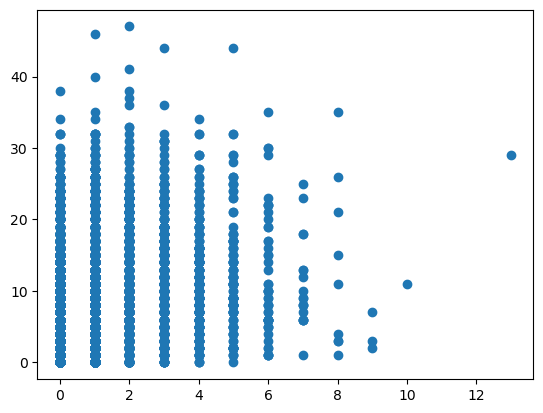

In [ ]:
import matplotlib.pyplot as plt

plt.plot(expr_ADT['CD63'], expr_RNA['Cd63'], 'o')

In [91]:
new_corr.sort_values(ascending=False).head(n=20)

CD107a      0.031070
CD29        0.017065
CD106       0.016551
CD317       0.016309
CD201       0.004168
CD63        0.002163
Notch       0.000553
Mac2       -0.000152
Notch      -0.012437
CD9        -0.013158
4-1BB            NaN
CD102            NaN
CD103            NaN
CD105            NaN
CD115            NaN
CD117            NaN
CD11a            NaN
CD11b-mh         NaN
CD11c            NaN
CD122            NaN
dtype: float64

In [90]:
orig_corr.sort_values("Cor")

,Protein,Gene,Cor,Mean_RNA_expr
126,Notch,Sbno2,-0.014432,0.741096
118,Notch,Sbno1,-0.013834,1.202861
116,Mac2,Lgals3,0.008389,9.397775
45,CD29,Itgb1,0.012668,2.492147
4,CD106,Vcam1,0.053864,0.523278
55,CD317,Bst2,0.077469,1.050668
33,CD201,Procr,0.102938,0.832056
176,CD9,Cd9,0.119955,1.861176
5,CD107a,Lamp1,0.147878,3.021922
167,CD63,Cd63,0.413217,4.793494


In [ ]:
imputed_data["Bst2"].corr(df_ADT["CD317"])

nan

## Test